# Lab 08

MSSV: 22302421

Name: Nguyễn Phúc Minh Châu

### Numerical IK Example

In [1]:
import roboticstoolbox as rtb
from spatialmath import SE3
import numpy as np

#Load robot model
robot = rtb.models.URDF.Panda()

#Define desired end-effector pose
T_des = SE3(0.5, 0.0, 0.3) * SE3.Rx(np.deg2rad(90))

#Solve IK using Levenberg-Marquardt
sol = robot.ikine_LM(T_des, q0=robot.qr)
q_sol = sol.q
print("success =", sol.success,
      "iterations =", sol.iterations,      
      "residual =", sol.residual)

#Verify with FK
T_check = robot.fkine(q_sol)
print("T_check:\n", T_check.A)
print("position error:", T_check.t - T_des.t)

success = True iterations = 7 residual = 2.4951301106573407e-08
T_check:
 [[ 1.00000000e+00 -6.10622408e-09 -2.82974043e-08  4.99999986e-01]
 [-2.82974041e-08  3.94600041e-08 -1.00000000e+00 -1.00870504e-08]
 [ 6.10622514e-09  1.00000000e+00  3.94600039e-08  2.99999984e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
position error: [-1.40199549e-08 -1.00870504e-08 -1.60343648e-08]


### Lab 8.1 — Analytic IK (2R)

Implement geometric IK from scratch. 

In [1]:
import numpy as np

def ik_2r(I1, I2, x, y):
    r2 = x**2 + y**2
    cos_t2 = (r2 - I1**2 - I2**2) / (2 * I1 * I2)

    if abs(cos_t2) > 1.0:
        return []
    def compute_theta1(theta2):
        phi = np.arctan2(y,x)
        beta = np.arctan2(I2 * np.sin(theta2), 
                          I1 + I2 * np.cos(theta2))
        return phi - beta
    
    t2_down = +np.arccos(cos_t2) #elbow down
    t2_up = -np.arccos(cos_t2) #elbow up

    sols = []
    for t2, label in [(t2_down, "elbow down"),
                      (t2_up, "elbow up")]:
        t1 = compute_theta1(t2)
        sols.append((t1, t2, label))
    return sols

#### Test & Visualize


Target: (1.0, 0.5)  |  I1=1.0, I2=1.0
  [elbow down]  θ1=-29.4°  θ2=112.0°  |  FK=(1.0000, 0.5000)  error=5.55e-17
  [elbow up]  θ1=82.6°  θ2=-112.0°  |  FK=(1.0000, 0.5000)  error=5.55e-17


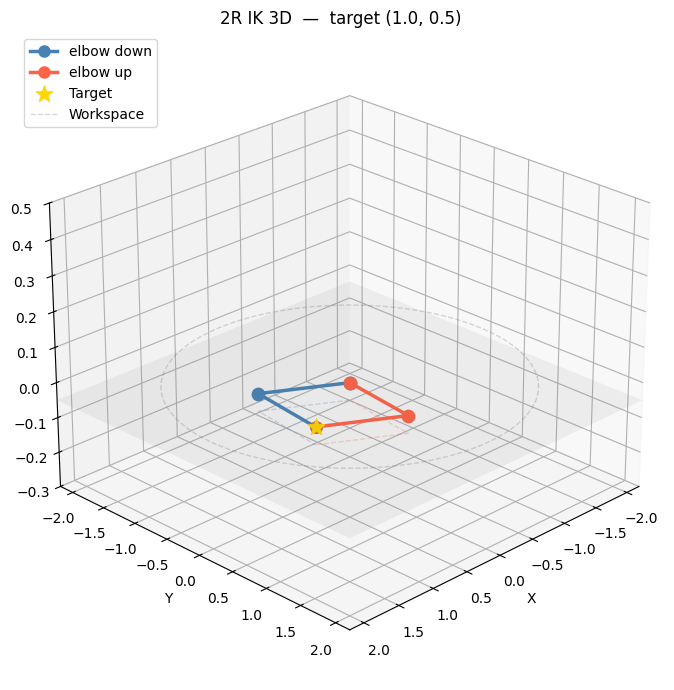

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def fk_2r(I1, I2, t1, t2):
    x = I1 * np.cos(t1) + I2 * np.cos(t1 + t2)
    y = I1 * np.sin(t1) + I2 * np.sin(t1 + t2)
    return x, y

def draw_arm(ax, I1, I2, t1, t2, label, color):
    j0 = np.array([0, 0, 0])
    j1 = np.array([I1 * np.cos(t1), I1 * np.sin(t1), 0])
    j2 = np.array([j1[0] + I2 * np.cos(t1 + t2),
                   j1[1] + I2 * np.sin(t1 + t2), 0])

    xs = [j0[0], j1[0], j2[0]]
    ys = [j0[1], j1[1], j2[1]]
    zs = [0, 0, 0]

    ax.plot(xs, ys, zs, '-o', color=color,
            linewidth=2.5, markersize=8, label=label)

    # Joint cylinders
    for joint, size in [(j0, 80), (j1, 80), (j2, 60)]:
        ax.scatter(*joint, s=size, color=color, zorder=5)

    # Shadow on ground
    ax.plot(xs, ys, [-0.05]*3, '--', color=color, alpha=0.25, linewidth=1)

def run_lab(I1, I2, x, y):
    print(f"\nTarget: ({x}, {y})  |  I1={I1}, I2={I2}")
    sols = ik_2r(I1, I2, x, y)

    if not sols:
        print("  Unreachable — no solution")
        return

    fig = plt.figure(figsize=(10, 7))
    ax  = fig.add_subplot(111, projection='3d')
    colors = ['steelblue', 'tomato']

    for (t1, t2, label), color in zip(sols, colors):
        xc, yc = fk_2r(I1, I2, t1, t2)
        err = np.sqrt((xc - x)**2 + (yc - y)**2)
        print(f"  [{label}]  θ1={np.degrees(t1):.1f}°  "
              f"θ2={np.degrees(t2):.1f}°  |  "
              f"FK=({xc:.4f}, {yc:.4f})  error={err:.2e}")
        draw_arm(ax, I1, I2, t1, t2, label, color)

    # Target point
    ax.scatter(x, y, 0, c='gold', s=150, marker='*',
               zorder=10, label='Target')

    # Workspace circle
    theta_range = np.linspace(0, 2*np.pi, 200)
    r_max = I1 + I2
    ax.plot(r_max * np.cos(theta_range),
            r_max * np.sin(theta_range),
            np.zeros(200), '--', color='gray',
            alpha=0.3, linewidth=1, label='Workspace')

    # Ground plane
    lim = (I1 + I2) * 1.1
    xx, yy = np.meshgrid(np.linspace(-lim, lim, 2),
                          np.linspace(-lim, lim, 2))
    ax.plot_surface(xx, yy, np.full_like(xx, -0.05),
                    alpha=0.08, color='gray')

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-0.3, 0.5)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f"2R IK 3D  —  target ({x}, {y})")
    ax.legend(loc='upper left')
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.show()

run_lab(1.0, 1.0, 1.0, 0.5)   # reachable → 2 sols


Target: (0.0, 0.0)  |  I1=1.0, I2=1.0
  [elbow down]  θ1=-90.0°  θ2=180.0°  |  FK=(0.0000, 0.0000)  error=1.22e-16
  [elbow up]  θ1=90.0°  θ2=-180.0°  |  FK=(0.0000, 0.0000)  error=1.22e-16


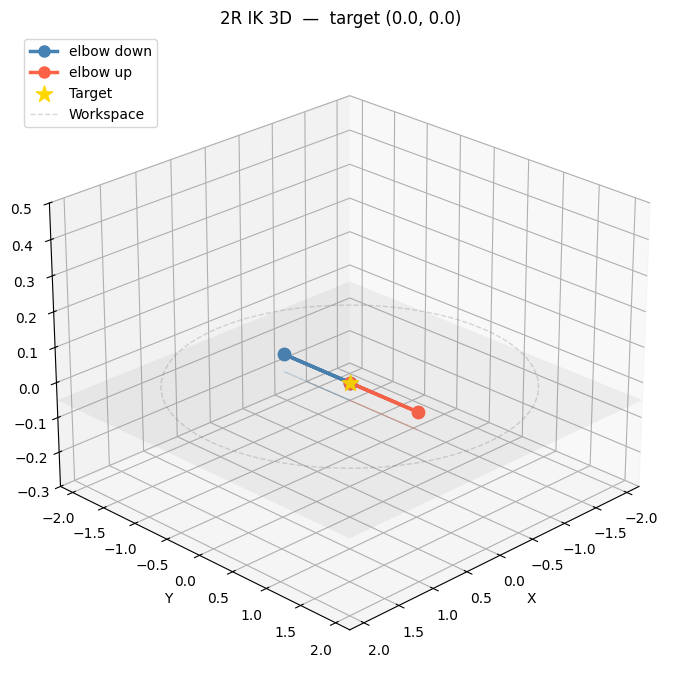

In [13]:
run_lab(1.0, 1.0, 0.0, 0.0)   # singular  → 1 sol

In [14]:
run_lab(1.0, 1.0, 2.5, 0.0)   # unreachable → 0 sols


Target: (2.5, 0.0)  |  I1=1.0, I2=1.0
  Unreachable — no solution


### Labs 8.2–8.4 — Numerical IK (6-DOF)

ikine_LM, workspace limits, convergence study. 

#### Lab 8.2
##### Numerical IK for 6-DOF Arm (Panda / Yahboom)

In [2]:
import roboticstoolbox as rtb
from spatialmath import SE3
import numpy as np

robot = rtb.models.URDF.Panda()

targets = [
    SE3(0.5, 0.0, 0.3),
    SE3(0.4, 0.2, 0.25)* SE3.Rz(np.deg2rad(30)),
    SE3(0.45, -0.15, 0.28)
]

q0 = robot.qr
for T_des in targets:
    sol = robot.ikine_LM(T_des, q0=q0)
    q_sol = sol.q
    T_check = robot.fkine(q_sol)
    err = T_check.t - T_des.t
    print(sol.success, sol.iterations, err)

True 17 [-6.41909487e-09 -3.47240911e-09 -1.59112257e-09]
True 13 [-2.40640841e-13 -5.24441601e-12  1.40870648e-12]
True 20 [-4.23974121e-08 -3.56620551e-07  2.07326389e-07]


##### IK with Joint Limits & Workspace Boundary

T1: success=False, joint_limits_ok=False, target=[0.85 0.   0.3 ]
T2: success=False, joint_limits_ok=False, target=[0.9 0.  0.1]
T3: success=False, joint_limits_ok=False, target=[0.  0.  1.2]
T4: success=True, joint_limits_ok=True, target=[0.3 0.7 0.3]
T5: success=False, joint_limits_ok=False, target=[0.95 0.   0.5 ]


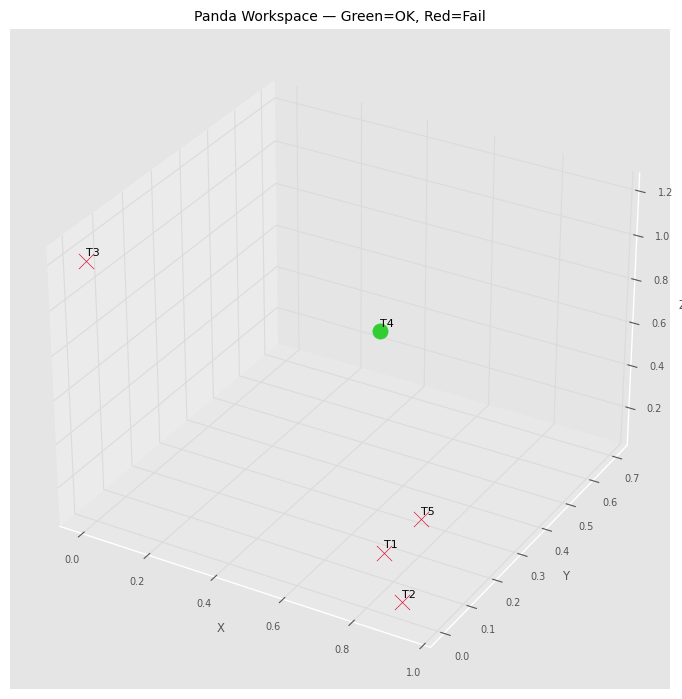

In [3]:
# Targets gần/vượt quá workspace
boundary_targets = [
    SE3(0.85, 0.0, 0.3),    # xa gần max reach
    SE3(0.9, 0.0, 0.1),     # rất xa + thấp
    SE3(0.0, 0.0, 1.2),     # quá cao
    SE3(0.3, 0.7, 0.3),     # lệch ngang nhiều
    SE3(0.95, 0.0, 0.5),    # ngoài workspace
]

results = []
for i, T_des in enumerate(boundary_targets):
    sol = robot.ikine_LM(T_des, q0=robot.qr)
    q_sol = sol.q

    # Kiểm tra joint limits của Panda
    qlim = robot.qlim  # shape (2, 7): [lower, upper]
    within_limits = np.all((q_sol >= qlim[0]) & (q_sol <= qlim[1]))

    results.append({
        'pose': i+1,
        'pos': T_des.t,
        'success': sol.success,
        'within_limits': within_limits,
        'q_sol': q_sol,
    })
    print(f"T{i+1}: success={sol.success}, "
          f"joint_limits_ok={within_limits}, "
          f"target={np.round(T_des.t, 2)}")

# Visualize workspace — scatter success/fail
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for r in results:
    color = 'limegreen' if r['success'] and r['within_limits'] else 'crimson'
    marker = 'o' if r['success'] else 'x'
    ax.scatter(*r['pos'], c=color, s=120, marker=marker, zorder=5)
    ax.text(r['pos'][0], r['pos'][1], r['pos'][2]+0.02,
            f"T{r['pose']}", fontsize=8)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Panda Workspace — Green=OK, Red=Fail')
plt.tight_layout()
plt.show()